In [6]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:
data = pd.read_csv("heart.csv")

In [8]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
print("Rows and Columns:", data.shape)

Rows and Columns: (303, 14)


In [13]:
print("Columns:", data.columns)

Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [14]:
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [16]:
X = data.drop("age", axis=1)
y = data["age"]

In [17]:
print(X.head())
print(y.head())

   sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  \
0    1   3       145   233    1        0      150      0      2.3      0   0   
1    1   2       130   250    0        1      187      0      3.5      0   0   
2    0   1       130   204    0        0      172      0      1.4      2   0   
3    1   1       120   236    0        1      178      0      0.8      2   0   
4    0   0       120   354    0        1      163      1      0.6      2   0   

   thal  target  
0     1       1  
1     2       1  
2     2       1  
3     2       1  
4     2       1  
0    63
1    37
2    41
3    56
4    57
Name: age, dtype: int64


In [18]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (303, 13)
Shape of y: (303,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (242, 13)
Testing set size: (61, 13)


In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Before Scaling:")
print(data.drop("age", axis=1).head())

print("After Scaling:")
print(X_train[:5])

Before Scaling:
   sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  \
0    1   3       145   233    1        0      150      0      2.3      0   0   
1    1   2       130   250    0        1      187      0      3.5      0   0   
2    0   1       130   204    0        0      172      0      1.4      2   0   
3    1   1       120   236    0        1      178      0      0.8      2   0   
4    0   0       120   354    0        1      163      1      0.6      2   0   

   thal  target  
0     1       1  
1     2       1  
2     2       1  
3     2       1  
4     2       1  
After Scaling:
[[ 0.72250438  0.00809909 -0.61685555  0.91403366 -0.38330071  0.8431327
   0.53278078 -0.67663234 -0.92086403  0.95390513 -0.68970073 -0.50904773
   0.90528939]
 [ 0.72250438 -0.97189094  1.1694912   0.43952674 -0.38330071 -1.04610909
  -1.75358236  1.47790748 -0.19378705  0.95390513 -0.68970073  1.17848036
  -1.10461916]
 [ 0.72250438  0.98808912  1.1694912  -0.30070405 -0.38

In [21]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.06557377049180328
Classification Report:
               precision    recall  f1-score   support

          34       0.00      0.00      0.00         1
          40       0.00      0.00      0.00         3
          41       0.25      0.50      0.33         2
          42       0.00      0.00      0.00         0
          43       0.00      0.00      0.00         1
          44       0.00      0.00      0.00         3
          45       0.00      0.00      0.00         3
          46       0.00      0.00      0.00         3
          47       0.00      0.00      0.00         0
          48       0.00      0.00      0.00         2
          50       0.00      0.00      0.00         3
          51       0.12      0.50      0.20         2
          52       0.50      0.25      0.33         4
          53       0.00      0.00      0.00         0
          54       0.00      0.00      0.00         3
          55       0.00      0.00      0.00         1
          56       0.00    

C:\Users\Admin\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Admin\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined

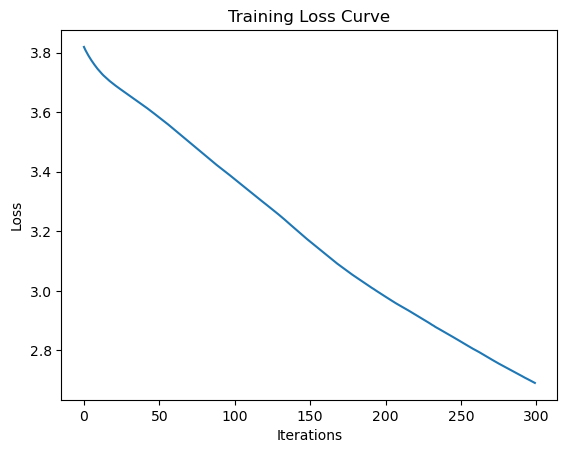

In [22]:
plt.plot(model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [23]:
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    solver='adam',
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

C:\Users\Admin\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(32, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


## Task Questions: 
# o	Print number of rows and columns. 
# o	Identify target column. o Check if any missing values exist. 


In [24]:
import pandas as pd

# load dataset (change filename if needed)
data = pd.read_csv("heart.csv")

# 1️⃣ Print number of rows and columns
print("Shape of dataset:", data.shape)
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

# 2️⃣ Identify target column
# 👉 replace 'target' with your actual column name
target_column = 'target'
print("Target column:", target_column)

# 3️⃣ Check missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

# Check if ANY missing value exists
print("\nAny missing value in dataset:", data.isnull().values.any())

Shape of dataset: (303, 14)
Rows: 303
Columns: 14
Target column: target

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Any missing value in dataset: False



# o Display first five examples of x and y. 
# o Print shape of x and y. 
# o What happens when we include target into x? 
# o Explain what axis =1 means? 
 


In [25]:
target = data.columns[-1]

x = data.drop(target, axis=1)
y = data[target]

print("Target column:", target)
print("X shape:", x.shape)
print("y shape:", y.shape)

Target column: target
X shape: (303, 13)
y shape: (303,)


# Change test_size to 0.3. 
# What happens if random_state is removed? 
# Print size of train and test sets. 


In [26]:
from sklearn.model_selection import train_test_split

# split data (test_size = 0.3)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# print sizes of train and test sets
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (212, 13)
X_test shape: (91, 13)
y_train shape: (212,)
y_test shape: (91,)


# Print first 5 rows before and after scaling. 
# What happens if we scale entire dataset before splitting? 
# Why do we use fit_transform() only on training data? 

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# BEFORE scaling
print("First 5 rows of X_train BEFORE scaling:")
print(x_train.head())

# scale data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# AFTER scaling
print("\nFirst 5 rows of X_train AFTER scaling:")
print(x_train_scaled[:5])

First 5 rows of X_train BEFORE scaling:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
124   39    0   2        94   199    0        1      179      0      0.0   
72    29    1   1       130   204    0        0      202      0      0.0   
15    50    0   2       120   219    0        1      158      0      1.6   
10    54    1   0       140   239    0        1      160      0      1.2   
163   38    1   2       138   175    0        1      173      0      0.0   

     slope  ca  thal  
124      2   0     2  
72       2   0     2  
15       1   0     2  
10       2   0     2  
163      2   4     2  

First 5 rows of X_train AFTER scaling:
[[-1.67339636 -1.39443338  0.95280942 -2.14786993 -0.88680513 -0.38202872
   0.8701389   1.27119034 -0.68718427 -0.93118976  0.955317   -0.67629057
  -0.54888242]
 [-2.76362385  0.71713717 -0.01367669 -0.02777897 -0.79502487 -0.38202872
  -1.03160798  2.2844851  -0.68718427 -0.93118976  0.955317   -0.67629057
  -0.54888242]

# Change hidden layers to (32,16). 
# Change activation to 'tanh'. 
# Increase max_iter to 500. 


In [28]:
from sklearn.neural_network import MLPClassifier

# ANN model with requested changes
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    max_iter=500,
    random_state=42
)

# train model
model.fit(x_train_scaled, y_train)

C:\Users\Admin\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(32, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


# Interpret confusion matrix. 
# Identify false positives. 
# Is accuracy enough for medical dataset? 
# Which metric is most important here? 

In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# predictions
y_pred = model.predict(x_test_scaled)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# extract values (binary classification)
TN, FP, FN, TP = cm.ravel()

print("\nTrue Positives:", TP)
print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

# metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[32  9]
 [ 8 42]]

True Positives: 42
True Negatives: 32
False Positives: 9
False Negatives: 8

Accuracy: 0.8131868131868132
Recall (Sensitivity): 0.84
Precision: 0.8235294117647058
F1 Score: 0.8316831683168316


# What happens if max_iter is small? 
# Does loss always decrease smoothly? 

C:\Users\Admin\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


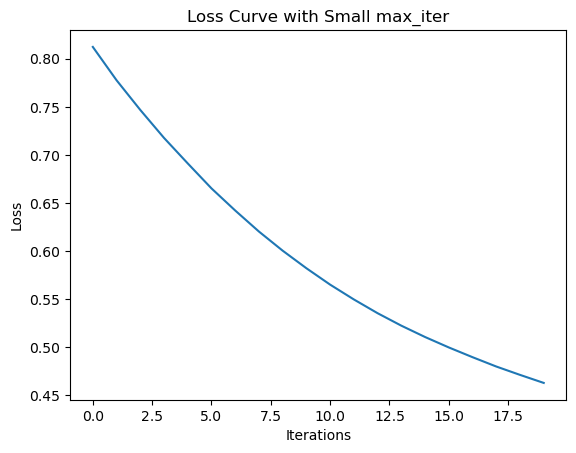

Final loss: 0.46272500287827123


In [30]:
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# small max_iter model
model_small = MLPClassifier(hidden_layer_sizes=(32,16),
                            activation='tanh',
                            max_iter=20,        # small iterations
                            random_state=42)

model_small.fit(x_train_scaled, y_train)

# plot loss curve
plt.plot(model_small.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve with Small max_iter")
plt.show()

print("Final loss:", model_small.loss_)

# Perform Binary Classification on diateses Data Set.

In [31]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score



# 2️⃣ Train-test split (test_size = 0.3)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# 3️⃣ Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 4️⃣ ANN model
model = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='tanh',
    max_iter=500,
    random_state=42
)

# 5️⃣ Train model
model.fit(x_train_scaled, y_train)

# 6️⃣ Predictions
y_pred = model.predict(x_test_scaled)

# 7️⃣ Evaluation
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))

Confusion Matrix:
 [[32  9]
 [ 8 42]]
Accuracy: 0.8131868131868132
Recall (Sensitivity): 0.84


C:\Users\Admin\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
